In [3]:
!pip3 install pandas numpy scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 22.7 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 18.6 MB/s  0:00:00 eta 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 0.0/8.3 MB ? eta -:--:--

In [1]:
import pandas as pd

customers = pd.read_csv("../data/customers.csv")
articles = pd.read_csv("../data/articles.csv")
transactions = pd.read_csv("../data/transactions_train.csv")

In [2]:
print("Customers:", customers.shape)
print("Articles:", articles.shape)
print("Transactions:", transactions.shape)

Customers: (1371980, 7)
Articles: (105542, 25)
Transactions: (31788324, 5)


In [3]:
customers.head()

,customer_id,FN,Active,club_member_status,fashion_news_frequency,age,postal_code
0,00000dbacae5abe5e23885899a1fa44253a17956c6d1c3...,NaN,NaN,ACTIVE,NONE,49.0,52043ee2162cf5aa7ee79974281641c6f11a68d276429a...
1,0000423b00ade91418cceaf3b26c6af3dd342b51fd051e...,NaN,NaN,ACTIVE,NONE,25.0,2973abc54daa8a5f8ccfe9362140c63247c5eee03f1d93...
2,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,NaN,NaN,ACTIVE,NONE,24.0,64f17e6a330a85798e4998f62d0930d14db8db1c054af6...
3,00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2...,NaN,NaN,ACTIVE,NONE,54.0,5d36574f52495e81f019b680c843c443bd343d5ca5b1c2...
4,00006413d8573cd20ed7128e53b7b13819fe5cfc2d801f...,1.0,1.0,ACTIVE,Regularly,52.0,25fa5ddee9aac01b35208d01736e57942317d756b32ddd...


In [4]:
articles.head()

,article_id,product_code,prod_name,product_type_no,product_type_name,product_group_name,graphical_appearance_no,graphical_appearance_name,colour_group_code,colour_group_name,...,department_name,index_code,index_name,index_group_no,index_group_name,section_no,section_name,garment_group_no,garment_group_name,detail_desc
0,108775015,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,9,Black,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
1,108775044,108775,Strap top,253,Vest top,Garment Upper body,1010016,Solid,10,White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
2,108775051,108775,Strap top (1),253,Vest top,Garment Upper body,1010017,Stripe,11,Off White,...,Jersey Basic,A,Ladieswear,1,Ladieswear,16,Womens Everyday Basics,1002,Jersey Basic,Jersey top with narrow shoulder straps.
3,110065001,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,9,Black,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."
4,110065002,110065,OP T-shirt (Idro),306,Bra,Underwear,1010016,Solid,10,White,...,Clean Lingerie,B,Lingeries/Tights,1,Ladieswear,61,Womens Lingerie,1017,"Under-, Nightwear","Microfibre T-shirt bra with underwired, moulde..."


In [5]:
transactions.head()

,t_dat,customer_id,article_id,price,sales_channel_id
0,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,663713001,0.050831,2
1,2018-09-20,000058a12d5b43e67d225668fa1f8d618c13dc232df0ca...,541518023,0.030492,2
2,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,505221004,0.015237,2
3,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687003,0.016932,2
4,2018-09-20,00007d2de826758b65a93dd24ce629ed66842531df6699...,685687004,0.016932,2


In [11]:
transactions.columns

Index(['t_dat', 'customer_id', 'article_id', 'price', 'sales_channel_id'], dtype='object')

In [6]:
transactions["t_dat"] = pd.to_datetime(transactions["t_dat"])

print("Date range:")
print(transactions["t_dat"].min(), "to", transactions["t_dat"].max())

purchases_per_customer = transactions.groupby("customer_id")["article_id"].count()

print("Purchase frequency stats:")
print(purchases_per_customer.describe())

one_time_buyers = (purchases_per_customer == 1).sum()
total_buyers = purchases_per_customer.shape[0]

print("One-time buyers:", one_time_buyers)
print("Percent one-time buyers:", round(100 * one_time_buyers / total_buyers, 2), "%")

Date range:
2018-09-20 00:00:00 to 2020-09-22 00:00:00
Purchase frequency stats:
count    1.362281e+06
mean     2.333463e+01
std      3.924225e+01
min      1.000000e+00
25%      3.000000e+00
50%      9.000000e+00
75%      2.700000e+01
max      1.895000e+03
Name: article_id, dtype: float64
One-time buyers: 131514
Percent one-time buyers: 9.65 %


In [12]:
customer_segments = pd.cut(
    purchases_per_customer,
    bins=[0,5,20,100,10000],
    labels=[
        "Low Activity",
        "Medium Activity",
        "High Activity",
        "Power Users"
    ]
)

In [13]:
customer_segments

customer_id
00000dbacae5abe5e23885899a1fa44253a17956c6d1c3d25f88aa139fdfc657      High Activity
0000423b00ade91418cceaf3b26c6af3dd342b51fd051eec9c12fb36984420fa      High Activity
000058a12d5b43e67d225668fa1f8d618c13dc232df0cad8ffe7ad4a1091e318    Medium Activity
00005ca1c9ed5f5146b52ac8639a40ca9d57aeff4d1bd2c5feb1ca5dff07c43e       Low Activity
00006413d8573cd20ed7128e53b7b13819fe5cfc2d801fe7fc0f26dd8d65a85a    Medium Activity
                                                                         ...       
ffffbbf78b6eaac697a8a5dfbfd2bfa8113ee5b403e4747568cac33e8c541831      High Activity
ffffcd5046a6143d29a04fb8c424ce494a76e5cdf4fab53481233731b5c4f8b7      High Activity
ffffcf35913a0bee60e8741cb2b4e78b8a98ee5ff2e6a1778d0116cffd259264      High Activity
ffffd7744cebcf3aca44ae7049d2a94b87074c3d4ffe38b2236865d949d4df6a    Medium Activity
ffffd9ac14e89946416d80e791d064701994755c3ab686a1eaf3458c36f52241       Low Activity
Name: article_id, Length: 1362281, dtype: category
Categories (4

In [14]:
purchase_counts = transactions.groupby("customer_id").size()

segments = pd.cut(
    purchase_counts,
    bins=[0,5,20,100,10000],
    labels=["Low","Medium","High","Power"]
)

segments.value_counts(normalize=True)

Low       0.368028
Medium    0.321333
High      0.269446
Power     0.041193
Name: proportion, dtype: float64

In [15]:
from sklearn.metrics import ndcg_score

In [7]:
top_products = transactions["article_id"].value_counts().head(10)
top_product_types = articles["product_type_name"].value_counts().head(10)

print("Top product IDs:")
print(top_products)

print("\nTop product types:")
print(top_product_types)


Top product IDs:
article_id
706016001    50287
706016002    35043
372860001    31718
610776002    30199
759871002    26329
464297007    25025
372860002    24458
610776001    22451
399223001    22236
706016003    21241
Name: count, dtype: int64

Top product types:
product_type_name
Trousers    11169
Dress       10362
Sweater      9302
T-shirt      7904
Top          4155
Blouse       3979
Jacket       3940
Shorts       3939
Shirt        3405
Vest top     2991
Name: count, dtype: int64


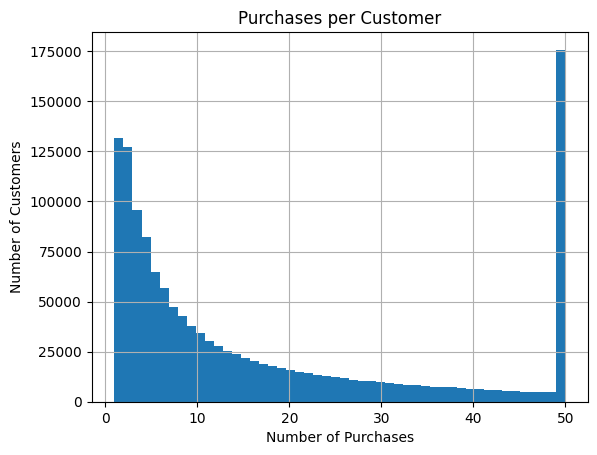

In [10]:
import sys, json, time, importlib.util
import matplotlib.pyplot as plt

# #region agent log
def _dbg(msg, data, hypothesis_id, run_id="post-fix"):
    entry = {"sessionId": "9191d1", "runId": run_id, "hypothesisId": hypothesis_id, "location": "01_exploration.ipynb:cell8", "message": msg, "data": data, "timestamp": int(time.time() * 1000)}
    with open("/Users/sravyapatakota/Documents/Code/realtime-ranking-system/.cursor/debug-9191d1.log", "a") as f:
        f.write(json.dumps(entry) + "\n")

_dbg("kernel environment", {"executable": sys.executable, "version": sys.version}, "H4")
_dbg("package paths", {"pandas": getattr(__import__("pandas"), "__file__", None), "matplotlib_spec": importlib.util.find_spec("matplotlib") is not None}, "H1")
try:
    import matplotlib
    _dbg("matplotlib import ok", {"version": matplotlib.__version__, "path": matplotlib.__file__}, "H2")
except Exception as e:
    _dbg("matplotlib import failed", {"error": type(e).__name__, "detail": str(e)}, "H2")
_dbg("plt defined after import", {"plt_module": str(plt)}, "H3")
# #endregion

purchases_per_customer.clip(upper=50).hist(bins=50)
plt.title("Purchases per Customer")
plt.xlabel("Number of Purchases")
plt.ylabel("Number of Customers")
plt.show()


## Key findings

1. The dataset has X customers, Y articles, and Z transactions.
2. A large share of customers have very few purchases, which creates a cold start problem.
3. Product purchases are not evenly distributed, so the recommender must avoid only recommending popular items.